# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Azzam Mujahid
- Email: azzam.project15@gmail.com
- Id Dicoding: M891D5Y0342

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Set style
sns.set_theme(style="whitegrid")

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('./dataset/data.csv', delimiter=';')
df.head(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df['Status'].value_counts()

Graduate    2209
Dropout     1421
Enrolled     794
Name: Status, dtype: int64

In [5]:
df_cleaned = df[df['Status'] != 'Enrolled'].copy()
df_cleaned['Status'].value_counts()

Graduate    2209
Dropout     1421
Name: Status, dtype: int64

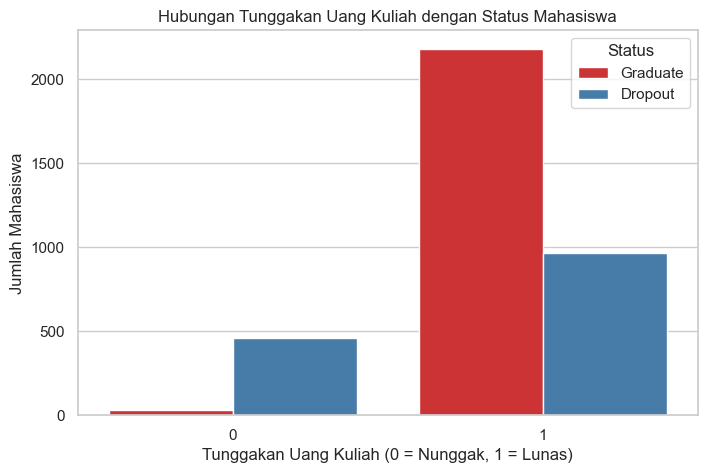

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x='Tuition_fees_up_to_date', hue='Status', palette='Set1')
plt.title('Hubungan Tunggakan Uang Kuliah dengan Status Mahasiswa')
plt.xlabel('Tunggakan Uang Kuliah (0 = Nunggak, 1 = Lunas)')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(title='Status')
plt.show()

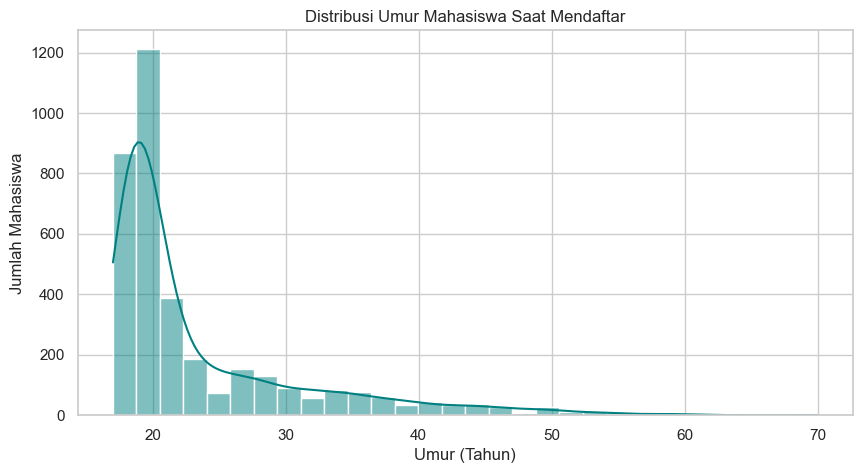

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_cleaned, x='Age_at_enrollment', kde=True, bins=30, color='teal')
plt.title('Distribusi Umur Mahasiswa Saat Mendaftar')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

C:\Users\NITRO\AppData\Local\Temp\ipykernel_1140\2677608086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Status', y='Curricular_units_1st_sem_grade', palette='Set2')


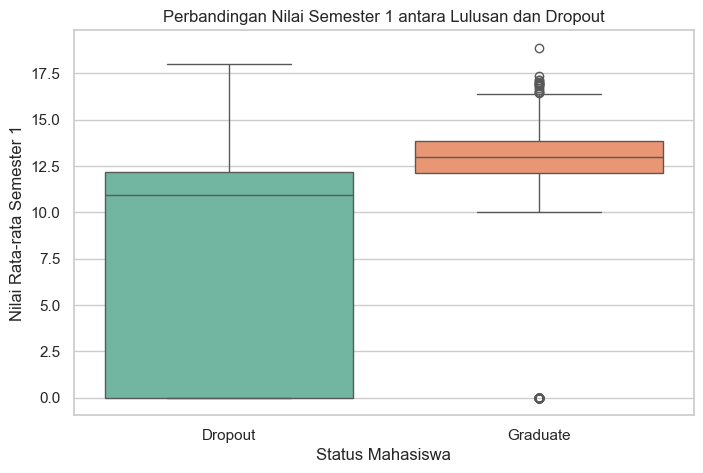

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Status', y='Curricular_units_1st_sem_grade', palette='Set2')
plt.title('Perbandingan Nilai Semester 1 antara Lulusan dan Dropout')
plt.xlabel('Status Mahasiswa')
plt.ylabel('Nilai Rata-rata Semester 1')
plt.show()

In [9]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3630 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                3630 non-null   int64  
 1   Application_mode                              3630 non-null   int64  
 2   Application_order                             3630 non-null   int64  
 3   Course                                        3630 non-null   int64  
 4   Daytime_evening_attendance                    3630 non-null   int64  
 5   Previous_qualification                        3630 non-null   int64  
 6   Previous_qualification_grade                  3630 non-null   float64
 7   Nacionality                                   3630 non-null   int64  
 8   Mothers_qualification                         3630 non-null   int64  
 9   Fathers_qualification                         3630 non-null   i

## Data Preparation / Preprocessing

In [10]:
from sklearn.model_selection import train_test_split

df_cleaned = df[df['Status'] != 'Enrolled'].copy()

df_cleaned['Status_Code'] = df_cleaned['Status'].replace({'Dropout': 1, 'Graduate': 0})

X = df_cleaned.drop(columns=['Status', 'Status_Code'])
y = df_cleaned['Status_Code']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2904, 36), (726, 36), (2904,), (726,))

In [11]:
numerical_cols = [
    'Previous_qualification_grade', 
    'Admission_grade', 
    'Age_at_enrollment',
    'Unemployment_rate', 
    'Inflation_rate', 'GDP',
    
    'Curricular_units_1st_sem_credited', 
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 
    'Curricular_units_1st_sem_without_evaluations',
    
    'Curricular_units_2nd_sem_credited', 
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 
    'Curricular_units_2nd_sem_without_evaluations'
]

categorical_cols = [col for col in X_train.columns if col not in numerical_cols]

In [12]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

set_config(display='diagram')
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


## Modeling

In [13]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

rf_model.fit(X_train, y_train)
rf_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
rf_model.score(X_test, y_test)

0.928374655647383

## Evaluation

In [15]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))

              precision    recall  f1-score   support

Graduate (0)       0.92      0.97      0.94       442
 Dropout (1)       0.94      0.87      0.90       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



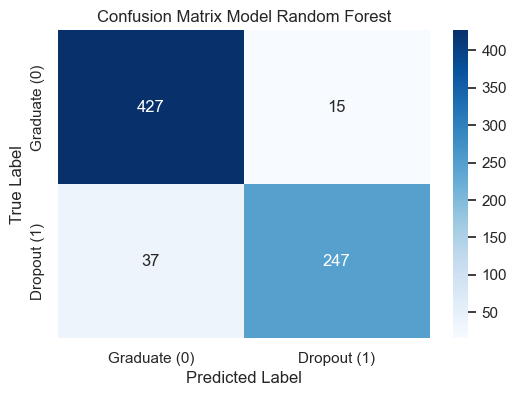

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Graduate (0)', 'Dropout (1)'], yticklabels=['Graduate (0)', 'Dropout (1)'])
plt.title('Confusion Matrix Model Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\NITRO\AppData\Local\Temp\ipykernel_1140\1177599191.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')


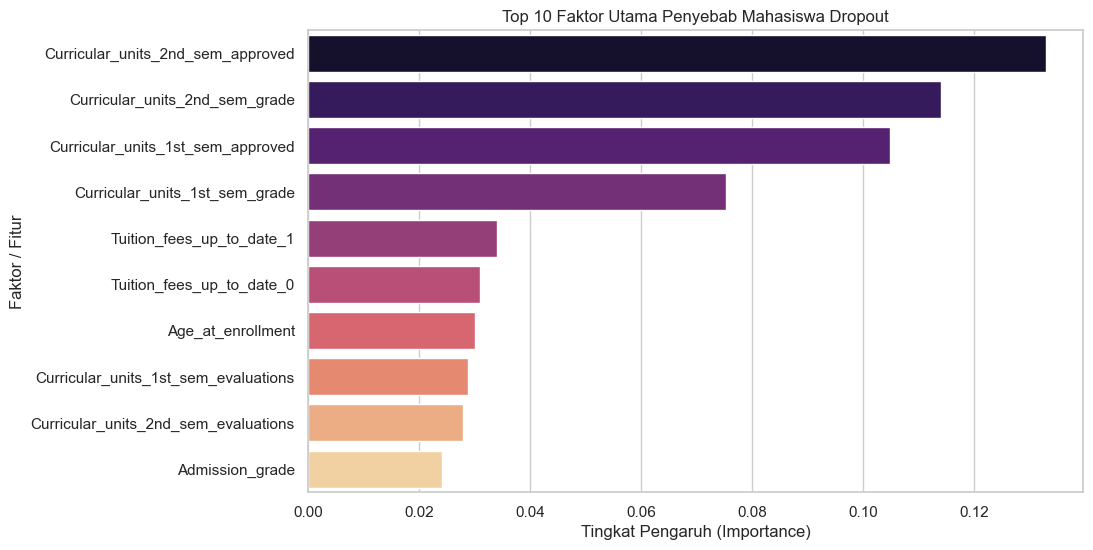

In [17]:
num_features = numerical_cols
cat_features = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)

all_features = num_features + list(cat_features)

importances = rf_model.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Faktor Utama Penyebab Mahasiswa Dropout')
plt.xlabel('Tingkat Pengaruh (Importance)')
plt.ylabel('Faktor / Fitur')
plt.show()

In [18]:
print("Top 10 Faktor Penyebab Mahasiswa Dropout:")
print(feat_imp_df[['Feature', 'Importance']])

Top 10 Faktor Penyebab Mahasiswa Dropout:
                                  Feature  Importance
15      Curricular_units_2nd_sem_approved    0.132917
16         Curricular_units_2nd_sem_grade    0.113979
9       Curricular_units_1st_sem_approved    0.104821
10         Curricular_units_1st_sem_grade    0.075224
233             Tuition_fees_up_to_date_1    0.034056
232             Tuition_fees_up_to_date_0    0.030914
2                       Age_at_enrollment    0.030119
8    Curricular_units_1st_sem_evaluations    0.028751
14   Curricular_units_2nd_sem_evaluations    0.027980
1                         Admission_grade    0.024214
